In [1]:
from Transformer import Transformer
import torch
import matplotlib.pyplot as plt

# MEMORY TEST

In [2]:
#Starting with memory this time for testing, still have to figure out autoregression
# This is like the previous memory test, but harder: Now the number sequences can be of a varying length, and the empty space can vary as well. Adding a special "*" character to signify "message has ended"
code_alphabet = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: "6", 7: "7", 8: "8", 9: "9", 10: "-", 11: ":", 12: "*"}
num_messages = 1000
code_lengths = torch.randint(3, 6, (num_messages,))
empty_lengths = torch.randint(5, 10, (num_messages,))
goal_length = 20
torch.manual_seed(0)
one_hots = torch.eye(13)
messages = []
responses = []
targets = []
#BUILDS THE MESSAGE
for code_length, empty_length in zip(code_lengths, empty_lengths):
    message_length = code_length * 2 + empty_length
    code = one_hots[torch.randint(0, 10, (code_length,))]  #Code is a sequence of random integers from 0-9
    empty = one_hots[torch.full((empty_length,), 10)]  #Empty space is a sequence of "-" characters
    code_space = one_hots[torch.full((code_length - 1,), 10)] #Extra "-" characters representing the code space
    start = one_hots[torch.full((1,), 11)] #Start symbol for the code
    message_ended = one_hots[torch.full((goal_length - message_length,), 12)] #MESSAGE ENDED sequence
    #print(code.shape, empty.shape, start.shape, code_space.shape, message_ended.shape)
    message = torch.cat([code, empty, start, code_space, message_ended], dim=0)
    #BUILDS THE RESPONSE
    pre_message = one_hots[torch.full((code_length + empty_length,), 10)]
    response = torch.cat([pre_message, code, message_ended], dim=0)
    target = response.argmax(dim=-1)

    messages.append(message)
    responses.append(response)
    targets.append(target)
messages = torch.stack(messages, dim=0)
responses = torch.stack(responses, dim=0)
targets = torch.stack(targets, dim=0)

In [3]:
cats = messages.argmax(dim=-1)
for element in targets[:100]:
    res = ""
    for elem in element:
        res += code_alphabet[elem.item()]
    print(res)

------------49303***
-----------97373****
-----------16698****
-----------6684*****
--------369*********
------------1441****
-----------9990*****
--------123*********
--------------05529*
----------18836*****
------------91735***
-----------21093****
---------110********
---------366********
-----------79634****
------------5082****
-----------827******
------------5008****
----------1961******
--------029*********
----------439*******
----------393*******
----------985*******
---------328********
------------56657***
-----------256******
--------654*********
------------081*****
---------785********
---------448********
------------44907***
-------------4533***
-------------7309***
--------------93181*
----------78410*****
----------404*******
---------970********
---------0149*******
------------95922***
--------214*********
------------9110****
-------------30676**
----------916*******
------------4105****
----------2581******
-----------8128*****
-----------038******
-----------92

In [4]:
def train_mem(model, optim, n_epochs):
    for epoch in range(n_epochs):
        if epoch % 10 == 1:
            print(epoch, loss.item())
        model.zero_grad()
        y = model(messages)
        loss = torch.nn.CrossEntropyLoss()(y.view(-1, 13), targets.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
    print(epoch, loss.item())

In [22]:
memformer = Transformer(in_dim=13, output_size=13, latent_size=128, n_heads=8, n_layers=4)

In [29]:
memoptim = torch.optim.AdamW(memformer.parameters(), lr=1e-4)

In [30]:
train_mem(memformer, memoptim, 100)

1 0.11724534630775452
11 0.08546768873929977
21 0.062296099960803986
31 0.039719581604003906
41 0.02260451577603817
51 0.011884505860507488
61 0.006137891672551632
71 0.0033802413381636143
81 0.0020964336581528187
91 0.0014561122516170144
99 0.0011286282679066062


In [31]:
def print_responses(model):
    res = model(messages)
    idxs = res.argmax(dim=-1)
    for i, idx in enumerate(idxs):
        res = ""
        resp = ""
        for j in range(len(idx)):
            res += code_alphabet[idx[j].item()]
            resp += code_alphabet[responses[i][j].argmax().item()]
        print(res, "\n" + resp)

In [32]:
print_responses(memformer)

------------49303*** 
------------49303***
-----------97373**** 
-----------97373****
-----------16698**** 
-----------16698****
-----------6684***** 
-----------6684*****
--------369********* 
--------369*********
------------1441**** 
------------1441****
-----------9990***** 
-----------9990*****
--------123********* 
--------123*********
--------------05529* 
--------------05529*
----------18836***** 
----------18836*****
------------91735*** 
------------91735***
-----------21093**** 
-----------21093****
---------110******** 
---------110********
---------366******** 
---------366********
-----------79634**** 
-----------79634****
------------5082**** 
------------5082****
-----------827****** 
-----------827******
------------5008**** 
------------5008****
----------1961****** 
----------1961******
--------029********* 
--------029*********
----------439******* 
----------439*******
----------393******* 
----------393*******
----------985******* 
----------985*******
---------32

# EXPONENTIAL DECAY

In [6]:
domain = torch.linspace(0, 1, 500) #Making it 10 times smaller for the sake of my computer, should have probably made a module if I knew the tests were going to be the same in advance.
exponents = torch.linspace(-3., 3, 100)
full_data = torch.exp(exponents[:, None] * domain[None, :])
train_data = full_data[::2]
test_data = full_data[1::2]
train_data.shape, test_data.shape

(torch.Size([50, 500]), torch.Size([50, 500]))

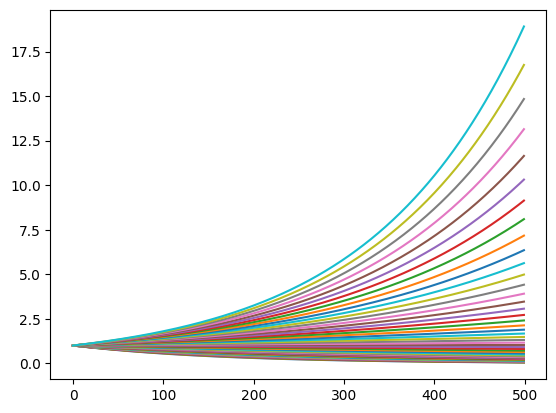

In [3]:
plt.plot(train_data.T)

In [2]:
autoregformer = Transformer(in_dim=1, output_size=1, latent_size=128, n_heads=8, n_layers=4).to("mps")

In [23]:
autoregoptim = torch.optim.AdamW(autoregformer.parameters(), lr=1e-4)

In [24]:
def train(model, optim, num_epochs, data, loss_fn=torch.nn.MSELoss()):
    model.train()
    data = data.to("mps")
    for epoch in range(num_epochs):
        if epoch % 10 == 1:
            print(epoch, loss.item())
        optim.zero_grad()
        y = model(data[:, :-1, :])
        loss = loss_fn(y, data[:, 1:, :])
        loss.backward()
        optim.step()
    print(epoch, loss.item())

In [25]:
train(autoregformer, autoregoptim, 100, train_data.unsqueeze(-1))

1 0.0022360626608133316
11 0.1294918805360794
21 0.006611627992242575
31 0.016084423288702965
41 0.004515743348747492
51 0.002476638415828347
61 0.0026010763831436634
71 0.002171037718653679
81 0.0018328060396015644
91 0.0016214163042604923
99 0.0014784331433475018


In [17]:
def generate(model, prompt, steps_to_generate):
    """
    Generates a sequence autoregressively.

    Args:
        model: The trained Transformer model.
        prompt: The initial sequence to start generation from (e.g., the first few points of a test curve).
                Shape should be [1, num_prompt_points, feature_dim].
        steps_to_generate: The number of new points to generate.

    Returns:
        The full generated sequence, including the prompt.
    """
    model.eval()  # Set the model to evaluation mode
    generated_sequence = prompt.clone() # Start with the prompt

    with torch.no_grad(): # Disable gradient calculations for efficiency
        for _ in range(steps_to_generate):
            # 1. The model's context is the entire sequence generated so far.
            # We pass the current sequence to the model.
            current_sequence_input = generated_sequence

            # 2. Get the model's predictions (logits) for the next token in the sequence.
            output_logits = model(current_sequence_input)

            # 3. We only care about the prediction for the VERY LAST time step.
            # The shape of output_logits is [batch, seq_len, features]. We want the last prediction.
            next_point_prediction = output_logits[:, -1:, :] # Shape: [1, 1, feature_dim]

            # 4. Append the new prediction to our sequence.
            generated_sequence = torch.cat([generated_sequence, next_point_prediction], dim=1)

    return generated_sequence

torch.Size([50, 99, 1]) torch.Size([50, 500])


Text(0.5, 0.98, 'Autoregression')

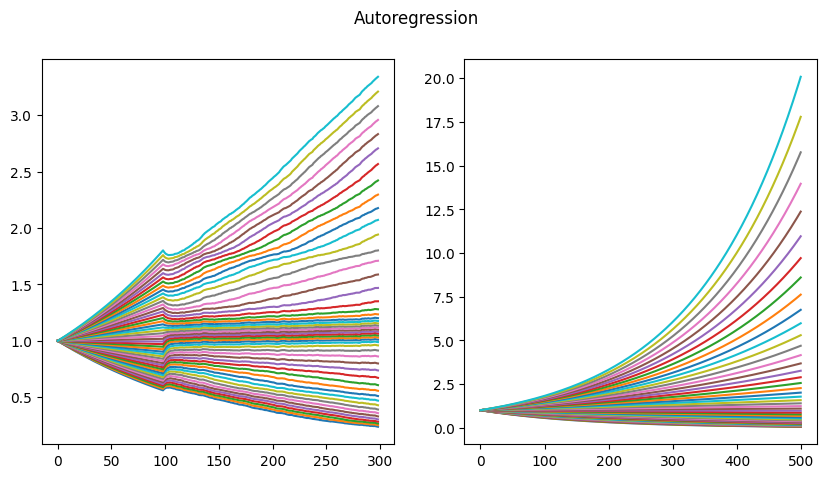

In [29]:
validation_data = test_data
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()
prompt = validation_data[:, :99, None].to("mps")
print(prompt.shape, validation_data.shape)
seq = generate(autoregformer, prompt, 200)
axs[0].plot(seq.cpu().detach().numpy().squeeze().T)
axs[1].plot(validation_data.T)
fig.suptitle("Autoregression")

Text(0.5, 0.98, 'Full Data')

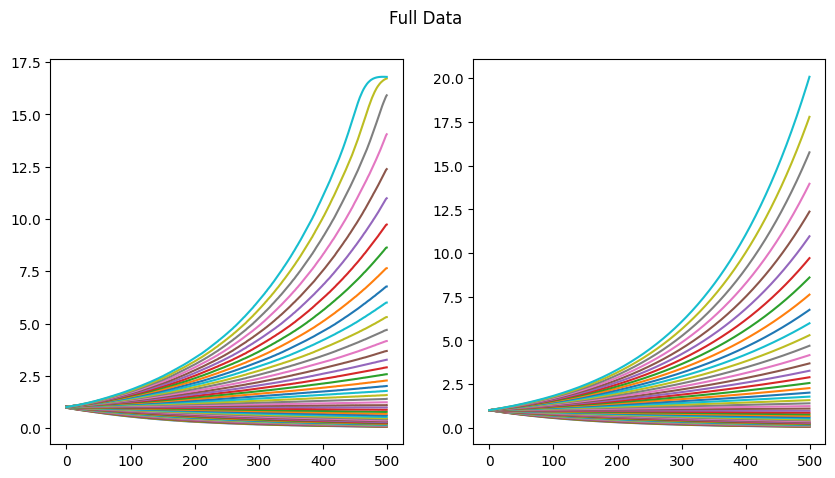

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs = axs.flatten()
y = autoregformer(validation_data.unsqueeze(-1).to("mps"))
axs[0].plot(y.cpu().detach().numpy().squeeze().T)
axs[1].plot(validation_data.T)
fig.suptitle("Full Data")
# Memory Test